In [1]:
EXP1 = "G6sulfur"
EXP2 = "G6solar"
EXP3 = "SSP245"

target_lat=30

In [2]:
target_var = "ta"
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_G6solar_SSP245_2091-2100_noNaN.nc"

In [3]:
# EXP1 = "G6sulfur"
# EXP2 = "G6solar"
# EXP3 = "SSP245"

# target_lat=30

# target_var = "ta"
# output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_G6solar_SSP245_2091-2100.nc"

import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    # "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    # "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    # "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2 and EXP3
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
    EXP3: EXP_REGISTRY[EXP3],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "G6solar", "SSP245"):
        return "20912100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "G6solar", "SSP245"):
        return ("2091-01-01", "2100-12")   # 10 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "day" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [5]:

# def vertical_levelwise_correlation(ds_ta):
#     """
#     Compute vertical level-wise correlation for temperature anomalies (vectorized).
#     """
#     import xarray as xr
#     import numpy as np
    
#     ta = ds_ta['ta']
    
#     # Group by month to get monthly climatology
#     ta_monthly_clim = ta.groupby('time.month').mean('time')
    
#     # Calculate anomalies by removing monthly climatology
#     ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
#     # Get dimensions
#     nmonths = 12
#     nlevels = len(ta.plev)
#     nlat = len(ta.lat)
#     nlon = len(ta.lon)
    
#     print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
#     print(f"    Original data shape: {ta.shape}")
#     print(f"    Dimension order: {ta.dims}")
    
#     # Initialize output array: (month, plev_i, plev_j, lat, lon)
#     vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
#     # Loop over each month
#     for imonth in range(1, 13):
#         print(f"    Processing month {imonth}/12", end='')
        
#         # Select data for this month
#         ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
#         if len(ta_month.time) < 2:
#             print(f" - skipping (only {len(ta_month.time)} time steps)")
#             continue
        
#         ntime = len(ta_month.time)
#         print(f" ({ntime} time steps)")
        
#         # Ensure correct dimension order: (time, plev, lat, lon)
#         ta_month = ta_month.transpose('time', 'plev', 'lat', 'lon')
#         data = ta_month.values
        
#         print(f"      Data shape after transpose: {data.shape}")
        
#         # Reshape to (ntime, plev, nlat*nlon)
#         data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
#         # Loop over each pair of levels
#         for i in range(nlevels):  # ordinate (response)
#             for j in range(nlevels):  # abscissa (predictor)
#                 # Extract all spatial points for these two levels
#                 x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
#                 y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
#                 # Compute correlation coefficient for all grid points at once
#                 # Using numpy correlation formula: corr = cov(x,y) / (std(x) * std(y))
                
#                 # Remove time mean for each grid point
#                 x_mean = np.nanmean(x, axis=0, keepdims=True)
#                 y_mean = np.nanmean(y, axis=0, keepdims=True)
#                 x_anom = x - x_mean
#                 y_anom = y - y_mean
                
#                 # Compute covariance and standard deviations
#                 cov = np.nanmean(x_anom * y_anom, axis=0)
#                 std_x = np.nanstd(x, axis=0)
#                 std_y = np.nanstd(y, axis=0)
                
#                 # Compute correlation
#                 with np.errstate(divide='ignore', invalid='ignore'):
#                     corr = cov / (std_x * std_y)
                
#                 # Reshape back to (nlat, nlon) and store
#                 vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
#     # Create output dataset
#     ds_out = xr.Dataset(
#         {
#             'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
#         },
#         coords={
#             'month': np.arange(1, 13),
#             'plev_i': ta.plev.values,
#             'plev_j': ta.plev.values,
#             'lat': ta.lat.values,
#             'lon': ta.lon.values
#         },
#         attrs={
#             'description': 'Vertical level-wise correlation of temperature anomalies',
#             'method': 'Pearson correlation between T anomalies at level i vs level j',
#             'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
#             'anomaly_base': 'Monthly climatology removed',
#             'note': 'Months with <2 time steps are skipped (NaN)'
#         }
#     )
    
#     return ds_out

In [6]:
# """
# CORRELATION SECTION
# """


# import os

# if not os.path.exists(output_file):
#     print('#'*40)
#     print("File does not exist — running code")
#     print('#'*40)


#     # ================================================================
#     # MAIN PROCESSING LOOP
#     # ================================================================
    
#     all_results = {}
    
#     for model_name, model_meta in MODELS.items():
    
#         vcorr_by_exp = {}  # Store all components for each experiment
#         seasonal_data = {}      # Store seasonal means by year
    
#         # ----------------------------
#         # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#         # ----------------------------
#         for exp, meta in EXPERIMENTS.items():
    
#             # --- special-case ensemble override ---
#             if model_name == "CESM2-WACCM":
#                 ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#             else:
#                 ensemble = model_meta["ensemble"]
    
#             def make_base(vname):
#                 return (
#                     CEDA_BASE
#                     / meta["project"]
#                     / model_meta["institution"]
#                     / model_name
#                     / meta["scenario"]
#                     / ensemble
#                     / "Amon"
#                     / vname
#                     / model_meta["grid"]
#                     / "latest"
#                 )
    

#             # target_var = "wap"
#             base_ta = make_base("ta")

            
#             ####### Handle ALTERNATE base paths ######
#             ds_ta = load_model_data_alt_path(base_ta, meta["project"], model_meta["institution"], 
#                                               model_name, meta["scenario"], 
#                                               ensemble, model_meta["grid"], mf, "ta")


#             #Slicing data
#             t_start, t_end = _time_slice(exp)
#             ds_sliced = ds_ta.sel(time=slice(t_start, t_end))
            
#             # Roll and regrid
#             ds_ta = roll_and_regrid_3d(ds_sliced, target_lat=30)
            
#             print(f"  [{model_name}] {exp}: ta loaded {ds_ta.sizes['time']} months "
#                   f"({ds_ta.time.values[0]} → {ds_ta.time.values[-1]})")

            
#             # Calculate vertical correlation
#             print(f"  [{model_name}] {exp}: Calculating vertical correlation")
#             vcorr = vertical_levelwise_correlation(ds_ta)
#             # vcorr = VPATCORR_pattern_vertical(ds_ta)
            
#             # Store for this experiment
#             vcorr_by_exp[exp] = vcorr
    
#         # After all experiments for this model
#         all_results[model_name] = vcorr_by_exp
    
    
#     # ================================================================
#     # 5) CREATE OUTPUT NETCDF FILE
#     # ================================================================
    
#     # Stack all models into one dataset
#     model_list = []
#     for model_name in all_results.keys():
#         exp_list = []
#         for exp in EXPERIMENTS.keys():
#             if exp in all_results[model_name]:
#                 ds = all_results[model_name][exp]
#                 ds = ds.expand_dims({'experiment': [exp]})
#                 exp_list.append(ds)
        
#         # Combine experiments for this model
#         if exp_list:
#             ds_model = xr.concat(exp_list, dim='experiment')
#             ds_model = ds_model.expand_dims({'model': [model_name]})
#             model_list.append(ds_model)
    
#     # Combine all models
#     ds_combined = xr.concat(model_list, dim='model')
    
#     # Save
#     print(f"\nSaving to {output_file}...")
#     ds_combined.to_netcdf(output_file)
#     print(f"✓ Saved successfully!")
#     print(f"  Dimensions: {dict(ds_combined.dims)}")
#     print(f"  Variables: {list(ds_combined.data_vars)}")

# else:
#     print('#'*40)
#     print(f"{output_file} already exists — skipping its computation")
#     print('#'*40)

In [7]:

# def vertical_levelwise_correlation(ds_ta):
#     """
#     Compute vertical level-wise correlation for temperature anomalies (vectorized).
#     """
#     import xarray as xr
#     import numpy as np
    
#     ta = ds_ta['ta']
    
#     # Group by month to get monthly climatology
#     ta_monthly_clim = ta.groupby('time.month').mean('time')
    
#     # Calculate anomalies by removing monthly climatology
#     ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
#     # Get dimensions
#     nmonths = 12
#     nlevels = len(ta.plev)
#     nlat = len(ta.lat)
#     nlon = len(ta.lon)
    
#     print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
#     print(f"    Original data shape: {ta.shape}")
#     print(f"    Dimension order: {ta.dims}")
    
#     # Initialize output array: (month, plev_i, plev_j, lat, lon)
#     vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
#     # Loop over each month
#     for imonth in range(1, 13):
#         print(f"    Processing month {imonth}/12", end='')
        
#         # Select data for this month
#         ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
#         if len(ta_month.time) < 2:
#             print(f" - skipping (only {len(ta_month.time)} time steps)")
#             continue
        
#         ntime = len(ta_month.time)
#         print(f" ({ntime} time steps)")
        
#         # Ensure correct dimension order: (time, plev, lat, lon)
#         ta_month = ta_month.transpose('time', 'plev', 'lat', 'lon')
#         data = ta_month.values
        
#         print(f"      Data shape after transpose: {data.shape}")
        
#         # Reshape to (ntime, plev, nlat*nlon)
#         data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
#         # Loop over each pair of levels
#         for i in range(nlevels):  # ordinate (response)
#             for j in range(nlevels):  # abscissa (predictor)
#                 # Extract all spatial points for these two levels
#                 x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
#                 y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
#                 # Compute correlation coefficient for all grid points at once
#                 # Using numpy correlation formula: corr = cov(x,y) / (std(x) * std(y))
                
#                 # Remove time mean for each grid point
#                 x_mean = np.nanmean(x, axis=0, keepdims=True)
#                 y_mean = np.nanmean(y, axis=0, keepdims=True)
#                 x_anom = x - x_mean
#                 y_anom = y - y_mean
                
#                 # Compute covariance and standard deviations
#                 cov = np.nanmean(x_anom * y_anom, axis=0)
#                 std_x = np.nanstd(x, axis=0)
#                 std_y = np.nanstd(y, axis=0)
                
#                 # Compute correlation
#                 with np.errstate(divide='ignore', invalid='ignore'):
#                     corr = cov / (std_x * std_y)
                
#                 # Reshape back to (nlat, nlon) and store
#                 vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
#     # Create output dataset
#     ds_out = xr.Dataset(
#         {
#             'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
#         },
#         coords={
#             'month': np.arange(1, 13),
#             'plev_i': ta.plev.values,
#             'plev_j': ta.plev.values,
#             'lat': ta.lat.values,
#             'lon': ta.lon.values
#         },
#         attrs={
#             'description': 'Vertical level-wise correlation of temperature anomalies',
#             'method': 'Pearson correlation between T anomalies at level i vs level j',
#             'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
#             'anomaly_base': 'Monthly climatology removed',
#             'note': 'Months with <2 time steps are skipped (NaN)'
#         }
#     )
    
#     return ds_out

# #########################################################################################

# """
# CORRELATION SECTION
# """
# import os
# import xarray as xr

# # ================================================================
# # OPENDAP URLs for IPSL-CM6A-LR (daily, 2020–2100)
# # ================================================================
# OPENDAP_URLS = {
#     "IPSL-CM6A-LR": {
#         "G6sulfur": "https://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/v20200709/ta_day_IPSL-CM6A-LR_G6sulfur_r1i1p1f1_gr_20200101-21001231.nc",
#         "G6solar":  "https://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6solar/r1i1p1f1/day/ta/gr/v20200723/ta_day_IPSL-CM6A-LR_G6solar_r1i1p1f1_gr_20200101-21001231.nc",
#         "ssp245":   "http://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp245/r1i1p1f1/day/ta/gr/v20190119/ta_day_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150101-21001231.nc",
#     }
# }

# # Time slice override for OpenDAP / daily data
# OPENDAP_TIME_SLICE = ("2091-01-01", "2100-12-31")


# def load_ta_opendap(model_name, exp):
#     """Load ta from OpenDAP for models that have a URL registered."""
#     url = OPENDAP_URLS.get(model_name, {}).get(exp)
#     if url is None:
#         return None
#     print(f"  [{model_name}] {exp}: Loading ta from OpenDAP (daily)")
#     ds = xr.open_dataset(url, engine="netcdf4", chunks={"time": 365})
#     return ds


# def load_ta_data(model_name, exp, meta, model_meta, mf):
#     """
#     Dispatcher: try CEDA path first; fall back to OpenDAP if the path
#     does not exist or raises an error.

#     Returns (ds_ta, time_override) where time_override is either None
#     (use _time_slice as normal) or a (t_start, t_end) tuple.
#     """
#     # ---- 1. Try CEDA ------------------------------------------------
#     if model_name == "CESM2-WACCM":
#         ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#     else:
#         ensemble = model_meta["ensemble"]

#     def make_base(vname):
#         return (
#             CEDA_BASE
#             / meta["project"]
#             / model_meta["institution"]
#             / model_name
#             / meta["scenario"]
#             / ensemble
#             / "Amon"
#             / vname
#             / model_meta["grid"]
#             / "latest"
#         )

#     base_ta = make_base("ta")
#     ceda_ok = False

#     try:
#         ds_ta = load_model_data_alt_path(
#             base_ta, meta["project"], model_meta["institution"],
#             model_name, meta["scenario"],
#             ensemble, model_meta["grid"], mf, "ta"
#         )
#         # Quick sanity-check that we actually got data
#         if ds_ta is not None and ds_ta.sizes.get("time", 0) > 0:
#             ceda_ok = True
#             print(f"  [{model_name}] {exp}: ta loaded from CEDA ({ds_ta.sizes['time']} months)")
#     except Exception as e:
#         print(f"  [{model_name}] {exp}: CEDA load failed ({e}); trying OpenDAP …")

#     if ceda_ok:
#         return ds_ta, None          # use normal _time_slice

#     # ---- 2. Fall back to OpenDAP ------------------------------------
#     ds_ta = load_ta_opendap(model_name, exp)
#     if ds_ta is None:
#         raise FileNotFoundError(
#             f"No CEDA data and no OpenDAP URL registered for {model_name} / {exp}"
#         )

#     # Daily → monthly mean so the rest of the pipeline stays unchanged
#     ds_ta = ds_ta.resample(time="1MS").mean("time")
#     print(f"  [{model_name}] {exp}: ta resampled to monthly ({ds_ta.sizes['time']} months)")

#     return ds_ta, OPENDAP_TIME_SLICE   # override time slice to 2091–2100


# # ================================================================
# # MAIN PROCESSING LOOP
# # ================================================================
# if not os.path.exists(output_file):
#     print('#' * 40)
#     print("File does not exist — running code")
#     print('#' * 40)

#     all_results = {}

#     for model_name, model_meta in MODELS.items():

#         vcorr_by_exp = {}

#         # ----------------------------
#         # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#         # ----------------------------
#         for exp, meta in EXPERIMENTS.items():

#             # --- load (CEDA first, OpenDAP fallback) ---
#             ds_ta, time_override = load_ta_data(model_name, exp, meta, model_meta, mf)

#             # --- time slice ---
#             if time_override is not None:
#                 t_start, t_end = time_override
#             else:
#                 t_start, t_end = _time_slice(exp)

#             ds_sliced = ds_ta.sel(time=slice(t_start, t_end))

#             # Roll and regrid
#             ds_ta_proc = roll_and_regrid_3d(ds_sliced, target_lat=30)

#             print(f"  [{model_name}] {exp}: ta sliced to {ds_ta_proc.sizes['time']} months "
#                   f"({ds_ta_proc.time.values[0]} → {ds_ta_proc.time.values[-1]})")

#             # Calculate vertical correlation
#             print(f"  [{model_name}] {exp}: Calculating vertical correlation")
#             vcorr = vertical_levelwise_correlation(ds_ta_proc)

#             vcorr_by_exp[exp] = vcorr

#         all_results[model_name] = vcorr_by_exp

#     # ================================================================
#     # 5) CREATE OUTPUT NETCDF FILE
#     # ================================================================

#     model_list = []
#     for model_name in all_results.keys():
#         exp_list = []
#         for exp in EXPERIMENTS.keys():
#             if exp in all_results[model_name]:
#                 ds = all_results[model_name][exp]
#                 ds = ds.expand_dims({'experiment': [exp]})
#                 exp_list.append(ds)

#         if exp_list:
#             ds_model = xr.concat(exp_list, dim='experiment')
#             ds_model = ds_model.expand_dims({'model': [model_name]})
#             model_list.append(ds_model)

#     ds_combined = xr.concat(model_list, dim='model')

#     print(f"\nSaving to {output_file}...")
#     ds_combined.to_netcdf(output_file)          # ← typo fixed
#     print(f"✓ Saved successfully!")
#     print(f"  Dimensions: {dict(ds_combined.dims)}")
#     print(f"  Variables: {list(ds_combined.data_vars)}")

# else:
#     print('#' * 40)
#     print(f"{output_file} already exists — skipping its computation")
#     print('#' * 40)

In [8]:
def vertical_levelwise_correlation(ds_ta):
    """
    Compute vertical level-wise correlation for temperature anomalies (vectorized).
    """
    import xarray as xr
    import numpy as np
    
    ta = ds_ta['ta']
    
    # Group by month to get monthly climatology
    ta_monthly_clim = ta.groupby('time.month').mean('time')
    
    # Calculate anomalies by removing monthly climatology
    ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
    # Get dimensions
    nmonths = 12
    nlevels = len(ta.plev)
    nlat = len(ta.lat)
    nlon = len(ta.lon)
    
    print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
    print(f"    Original data shape: {ta.shape}")
    print(f"    Dimension order: {ta.dims}")
    
    # Initialize output array: (month, plev_i, plev_j, lat, lon)
    vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
    # Loop over each month
    for imonth in range(1, 13):
        print(f"    Processing month {imonth}/12", end='')
        
        # Select data for this month
        ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
        if len(ta_month.time) < 2:
            print(f" - skipping (only {len(ta_month.time)} time steps)")
            continue
        
        ntime = len(ta_month.time)
        print(f" ({ntime} time steps)")
        
        # Ensure correct dimension order: (time, plev, lat, lon)
        ta_month = ta_month.transpose('time', 'plev', 'lat', 'lon')
        data = ta_month.values
        
        print(f"      Data shape after transpose: {data.shape}")
        
        # Reshape to (ntime, plev, nlat*nlon)
        data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
        # Guard: if entire month slice is NaN, leave vcorr as NaN and move on
        if np.all(np.isnan(data_reshaped)):
            print(f"      WARNING: all-NaN data for month {imonth} — skipping")
            continue

        # Loop over each pair of levels
        for i in range(nlevels):  # ordinate (response)
            for j in range(nlevels):  # abscissa (predictor)
                x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
                y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
                # Skip level pairs that are entirely NaN
                if np.all(np.isnan(x)) or np.all(np.isnan(y)):
                    continue

                x_mean = np.nanmean(x, axis=0, keepdims=True)
                y_mean = np.nanmean(y, axis=0, keepdims=True)
                x_anom = x - x_mean
                y_anom = y - y_mean
                
                cov    = np.nanmean(x_anom * y_anom, axis=0)
                std_x  = np.nanstd(x, axis=0)
                std_y  = np.nanstd(y, axis=0)
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    corr = np.where((std_x == 0) | (std_y == 0), np.nan, cov / (std_x * std_y))
                
                # Clip to valid correlation range (floating-point safety)
                corr = np.clip(corr, -1.0, 1.0)

                vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
    ds_out = xr.Dataset(
        {'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)},
        coords={
            'month': np.arange(1, 13),
            'plev_i': ta.plev.values,
            'plev_j': ta.plev.values,
            'lat':    ta.lat.values,
            'lon':    ta.lon.values,
        },
        attrs={
            'description': 'Vertical level-wise correlation of temperature anomalies',
            'method':      'Pearson correlation between T anomalies at level i vs level j',
            'reference':   'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
            'anomaly_base':'Monthly climatology removed',
            'note':        'Months with <2 time steps, all-NaN slices, or zero-variance levels are NaN',
        }
    )
    return ds_out


# ================================================================
# OPENDAP URLs  —  add mirror fallbacks per experiment
# ================================================================
OPENDAP_URLS = {
    "IPSL-CM6A-LR": {
        "G6sulfur": [
            "https://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/v20200709/ta_day_IPSL-CM6A-LR_G6sulfur_r1i1p1f1_gr_20200101-21001231.nc",
            "https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip6/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/v20200709/ta_day_IPSL-CM6A-LR_G6sulfur_r1i1p1f1_gr_20200101-21001231.nc",
        ],
        "G6solar": [
            "https://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6solar/r1i1p1f1/day/ta/gr/v20200723/ta_day_IPSL-CM6A-LR_G6solar_r1i1p1f1_gr_20200101-21001231.nc",
            "https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip6/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6solar/r1i1p1f1/day/ta/gr/v20200723/ta_day_IPSL-CM6A-LR_G6solar_r1i1p1f1_gr_20200101-21001231.nc",
        ],
        "ssp245": [
            "http://esgf-node.ornl.gov/thredds/dodsC/css03_data/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp245/r1i1p1f1/day/ta/gr/v20190119/ta_day_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150101-21001231.nc",
            "https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp245/r1i1p1f1/day/ta/gr/v20190119/ta_day_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150101-21001231.nc",
        ],
    }
}

OPENDAP_TIME_SLICE = ("2091-01-01", "2100-12-31")


def _probe_opendap(url, t_start, t_end, timeout_s=30):
    """
    Try to open url via OPeNDAP and do a tiny test read on the sliced
    time window.  Returns an open (lazy) xarray Dataset, or None on any failure.
    """
    import signal

    def _timeout_handler(signum, frame):
        raise TimeoutError(f"OPeNDAP probe timed out after {timeout_s}s")

    signal.signal(signal.SIGALRM, _timeout_handler)
    signal.alarm(timeout_s)
    try:
        ds = xr.open_dataset(url, engine="netcdf4", chunks={"time": 365})
        # Lightweight check: read the first time-step of the slice
        _ = ds.sel(time=slice(t_start, t_end)).isel(time=0)['ta'].values
        signal.alarm(0)           # cancel alarm
        return ds
    except Exception as e:
        signal.alarm(0)
        print(f"      ✗ {url}\n        reason: {e}")
        return None


def load_ta_opendap(model_name, exp,
                    t_start=OPENDAP_TIME_SLICE[0],
                    t_end=OPENDAP_TIME_SLICE[1]):
    """
    Try each mirror URL in order; return the first that responds.
    Returns None if all mirrors fail.
    """
    urls = OPENDAP_URLS.get(model_name, {}).get(exp)
    if not urls:
        return None

    # Normalise to list so a single string still works
    if isinstance(urls, str):
        urls = [urls]

    for url in urls:
        print(f"  [{model_name}] {exp}: probing OpenDAP → {url.split('/')[2]}")
        ds = _probe_opendap(url, t_start, t_end)
        if ds is not None:
            print(f"  [{model_name}] {exp}: ✓ OpenDAP connection OK")
            return ds

    print(f"  [{model_name}] {exp}: ✗ ALL OpenDAP mirrors failed — experiment will be NaN-filled")
    return None


def _make_nan_vcorr(reference_ds, t_start, t_end):
    """
    Build an all-NaN vcorr dataset with the correct coordinates,
    derived from a reference xarray Dataset (any working experiment).
    Used when a source is completely unavailable.
    """
    import numpy as np

    ta_ref = reference_ds['ta']
    nlevels = len(ta_ref.plev)
    nlat    = len(ta_ref.lat)
    nlon    = len(ta_ref.lon)

    vcorr = np.full((12, nlevels, nlevels, nlat, nlon), np.nan)
    ds_nan = xr.Dataset(
        {'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)},
        coords={
            'month':  np.arange(1, 13),
            'plev_i': ta_ref.plev.values,
            'plev_j': ta_ref.plev.values,
            'lat':    ta_ref.lat.values,
            'lon':    ta_ref.lon.values,
        },
        attrs={'description': 'All-NaN placeholder — source data unavailable',
               'time_slice':  f"{t_start} to {t_end}"}
    )
    return ds_nan


def load_ta_data(model_name, exp, meta, model_meta, mf):
    """
    Dispatcher: CEDA first → OpenDAP fallback (with mirror list).
    Returns (ds_ta, time_override):
      - time_override=None  → use _time_slice(exp) as normal
      - time_override=(t0, t1) → use this slice instead
      - ds_ta=None          → source completely unavailable
    """
    # ---- 1. Try CEDA ------------------------------------------------
    if model_name == "CESM2-WACCM":
        ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
    else:
        ensemble = model_meta["ensemble"]

    def make_base(vname):
        return (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / vname
            / model_meta["grid"]
            / "latest"
        )

    ceda_ok = False
    try:
        ds_ta = load_model_data_alt_path(
            make_base("ta"), meta["project"], model_meta["institution"],
            model_name, meta["scenario"],
            ensemble, model_meta["grid"], mf, "ta"
        )
        if ds_ta is not None and ds_ta.sizes.get("time", 0) > 0:
            ceda_ok = True
            print(f"  [{model_name}] {exp}: ✓ ta loaded from CEDA ({ds_ta.sizes['time']} months)")
    except Exception as e:
        print(f"  [{model_name}] {exp}: CEDA load failed ({e}); trying OpenDAP …")

    if ceda_ok:
        return ds_ta, None

    # ---- 2. OpenDAP (with mirror fallback) --------------------------
    t_start, t_end = OPENDAP_TIME_SLICE
    ds_ta = load_ta_opendap(model_name, exp, t_start, t_end)

    if ds_ta is None:
        return None, OPENDAP_TIME_SLICE   # caller handles the None

    # Daily → monthly mean
    ds_ta = ds_ta.resample(time="1MS").mean("time")
    print(f"  [{model_name}] {exp}: resampled to monthly ({ds_ta.sizes['time']} months)")
    return ds_ta, OPENDAP_TIME_SLICE


# ================================================================
# MAIN PROCESSING LOOP
# ================================================================
import os

if not os.path.exists(output_file):
    print('#' * 40)
    print("File does not exist — running code")
    print('#' * 40)

    all_results  = {}
    _ref_ds      = {}   # store one working ds per model for NaN scaffold

    for model_name, model_meta in MODELS.items():

        vcorr_by_exp = {}

        for exp, meta in EXPERIMENTS.items():

            ds_ta, time_override = load_ta_data(model_name, exp, meta, model_meta, mf)

            t_start, t_end = time_override if time_override else _time_slice(exp)

            # ── source completely unavailable ──────────────────────────
            if ds_ta is None:
                print(f"  [{model_name}] {exp}: ⚠ no data — inserting NaN placeholder")
                ref = _ref_ds.get(model_name)
                if ref is not None:
                    vcorr_by_exp[exp] = _make_nan_vcorr(ref, t_start, t_end)
                else:
                    # No reference available yet; store sentinel and fill later
                    vcorr_by_exp[exp] = None
                continue

            # Cache a reference dataset for this model (for NaN scaffolding)
            if model_name not in _ref_ds:
                _ref_ds[model_name] = ds_ta

            # ── time slice ────────────────────────────────────────────
            ds_sliced   = ds_ta.sel(time=slice(t_start, t_end))

            if ds_sliced.sizes.get("time", 0) == 0:
                print(f"  [{model_name}] {exp}: ⚠ empty after time slice — NaN placeholder")
                vcorr_by_exp[exp] = _make_nan_vcorr(ds_ta, t_start, t_end)
                continue

            # ── regrid + correlation ──────────────────────────────────
            ds_ta_proc = roll_and_regrid_3d(ds_sliced, target_lat=30)

            print(f"  [{model_name}] {exp}: ta sliced to {ds_ta_proc.sizes['time']} months "
                  f"({ds_ta_proc.time.values[0]} → {ds_ta_proc.time.values[-1]})")

            print(f"  [{model_name}] {exp}: Calculating vertical correlation")
            vcorr_by_exp[exp] = vertical_levelwise_correlation(ds_ta_proc)

        # ── back-fill any None sentinels now that we have a reference ──
        ref = _ref_ds.get(model_name)
        for exp, v in vcorr_by_exp.items():
            if v is None:
                t_start, t_end = OPENDAP_TIME_SLICE
                if ref is not None:
                    print(f"  [{model_name}] {exp}: back-filling NaN placeholder")
                    vcorr_by_exp[exp] = _make_nan_vcorr(ref, t_start, t_end)
                else:
                    raise RuntimeError(
                        f"[{model_name}] {exp}: no data AND no reference dataset — "
                        "cannot construct NaN placeholder. Check your data sources."
                    )

        all_results[model_name] = vcorr_by_exp

    # ================================================================
    # CREATE OUTPUT NETCDF FILE
    # ================================================================
    model_list = []
    for model_name in all_results:
        exp_list = []
        for exp in EXPERIMENTS:
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp].expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment').expand_dims({'model': [model_name]})
            model_list.append(ds_model)

    ds_combined = xr.concat(model_list, dim='model')

    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables:  {list(ds_combined.data_vars)}")

else:
    print('#' * 40)
    print(f"{output_file} already exists — skipping its computation")
    print('#' * 40)

########################################
File does not exist — running code
########################################
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/Amon/ta/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest
  [IPSL-CM6A-LR] G6sulfur: ✓ ta loaded from CEDA (29585 months)
  [IPSL-CM6A-LR] G6sulfur: ta sliced to 3652 months (2091-01-01 12:00:00 → 2100-12-31 12:00:00)
  [IPSL-CM6A-LR] G6sulfur: Calculating vertical correlation
    Array dimensions: nlevels=8, nlat=25, nlon=144
    Original data shape: (8, 3652, 25, 144)
    Dimension order: ('plev', 'time', 'lat', 'lon')
    Processing month 1/12 (310 time steps)
      Data shape after transpose: (310, 8, 25, 144)
    Processing month 2/12 (282 time steps)
      Data shape after transpose: (282, 8, 25, 144)
    Proces

# Plotting

In [9]:
# Load the dataset
ds_corr = xr.open_dataset(output_file)

In [10]:
print('ds_corr', ds_corr)

ds_corr <xarray.Dataset> Size: 374MB
Dimensions:     (model: 1, experiment: 3, month: 12, plev_i: 19, plev_j: 19,
                 lat: 25, lon: 144)
Coordinates:
  * model       (model) <U12 48B 'IPSL-CM6A-LR'
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev_i      (plev_i) float32 76B 100.0 500.0 1e+03 ... 9.25e+04 1e+05
  * plev_j      (plev_j) float32 76B 100.0 500.0 1e+03 ... 9.25e+04 1e+05
  * lat         (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 25.0 27.5 30.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * experiment  (experiment) <U8 96B 'G6sulfur' 'G6solar' 'SSP245'
Data variables:
    vcorr       (model, experiment, month, plev_i, plev_j, lat, lon) float64 374MB ...
Attributes:
    description:   Vertical level-wise correlation of temperature anomalies
    method:        Pearson correlation between T anomalies at level i vs level j
    reference:     Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.23192...
    

In [11]:
# import matplotlib.pyplot as plt
# import numpy as np

# # select data
# da = ds_corr.vpatcorr.sel(
#     model='CESM2-WACCM',
#     experiment='SSP245',
#     month=[1,2,3,4,5,6,7,8,9,10,11,12]
# ).mean('month')

# plev = da.plev_i.values

# fig, ax = plt.subplots(figsize=(6, 5))

# cf = ax.contourf(
#     plev, plev, da.values,
#     levels=np.linspace(-1, 1, 81),
#     cmap='RdBu_r',
#     extend='both'
# )

# # ax.contour(
# #     plev, plev, da.values,
# #     levels=np.arange(-0.8, 1.0, 0.05),
# #     colors='k',
# #     linewidths=0.6
# # )

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.invert_xaxis()
# ax.invert_yaxis()

# ax.set_xlabel('Reference level (Pa)')
# ax.set_ylabel('Target level (Pa)')
# ax.set_title('Vertical pattern correlation (Annual, 30°S–30°N)')

# cbar = fig.colorbar(cf, ax=ax)
# cbar.set_label('Pattern correlation')

# plt.tight_layout()
# plt.show()

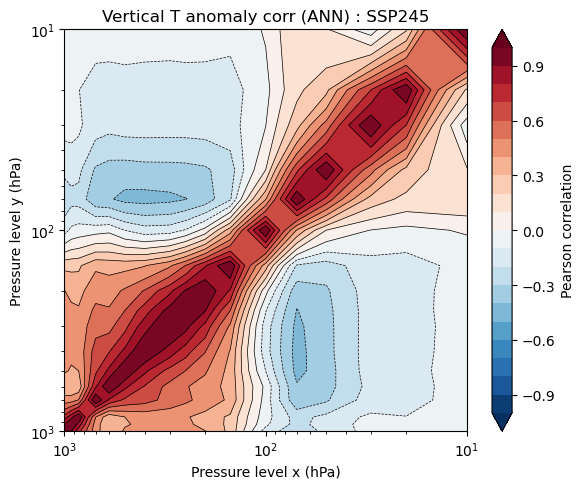

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='SSP245',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon']) # this is annual mean


# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,10)
ax.set_xlim(1000,10)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : SSP245')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

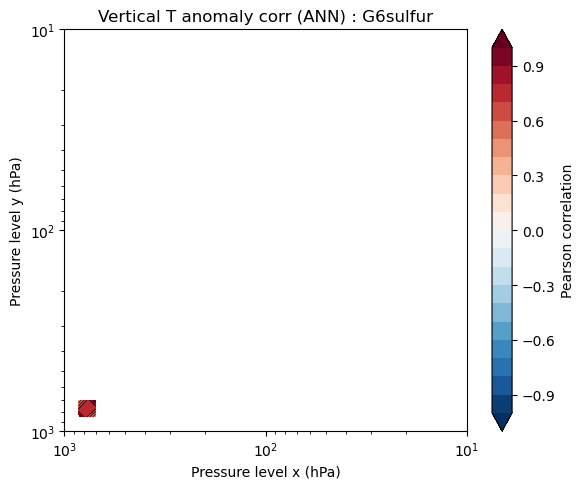

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6sulfur',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon']) # this is annual mean

# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,10)
ax.set_xlim(1000,10)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6sulfur')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

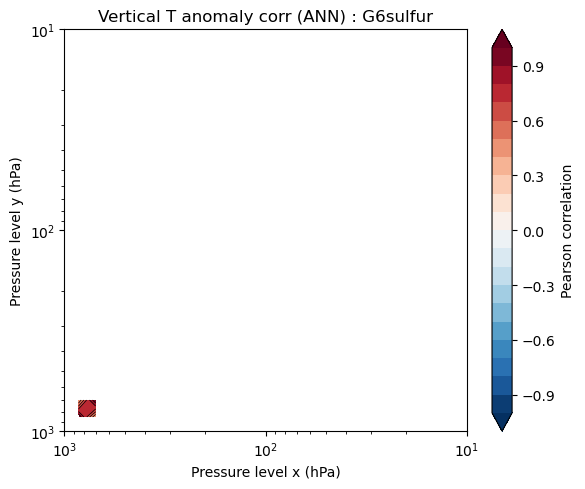

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6solar',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon']) # this is annual mean

# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,10)
ax.set_xlim(1000,10)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6sulfur')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

In [15]:
ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6sulfur',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

<xarray.Dataset> Size: 125MB
Dimensions:     (month: 12, plev_i: 19, plev_j: 19, lat: 25, lon: 144)
Coordinates:
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev_i      (plev_i) float32 76B 100.0 500.0 1e+03 ... 9.25e+04 1e+05
  * plev_j      (plev_j) float32 76B 100.0 500.0 1e+03 ... 9.25e+04 1e+05
  * lat         (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 25.0 27.5 30.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    experiment  <U8 32B 'G6sulfur'
Data variables:
    vcorr       (month, plev_i, plev_j, lat, lon) float64 125MB nan nan ... nan

Converting plev from Pa → hPa (max raw value: 100000)
Pressure levels (hPa): [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   70.   50.   30.   20.   10.    5.    1.]
N levels: 19


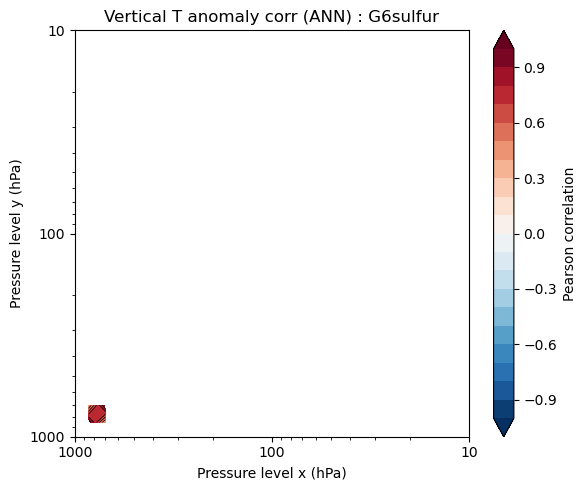

In [16]:
# --- Selection ---
ds = ds_corr.sel(
    experiment='G6sulfur',
    lat=slice(-30, 30),
).mean(dim='model')

ds_djf = ds.vcorr.mean(dim=['month', 'lat', 'lon'])

# --- Pressure levels: auto-detect Pa vs hPa ---
plev_raw = ds_djf.plev_i.values
plev_units = ds_corr.plev_i.attrs.get('units', '')

if plev_raw.max() > 10000 or 'Pa' in plev_units and 'hPa' not in plev_units:
    print(f"Converting plev from Pa → hPa (max raw value: {plev_raw.max():.0f})")
    plev = plev_raw / 100.0
else:
    plev = plev_raw

print(f"Pressure levels (hPa): {np.sort(plev)[::-1]}")
print(f"N levels: {len(plev)}")

# Sort levels descending (surface → TOA) for correct matrix orientation
sort_idx = np.argsort(plev)[::-1]
plev_sorted = plev[sort_idx]
data_sorted = ds_djf.values[np.ix_(sort_idx, sort_idx)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(
    plev_sorted, plev_sorted, data_sorted,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    plev_sorted, plev_sorted, data_sorted,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000, 10)
ax.set_xlim(1000, 10)
ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6sulfur')

# Nicer log-scale ticks
from matplotlib.ticker import LogLocator, LogFormatter
ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1.0]))
ax.yaxis.set_major_locator(LogLocator(base=10, subs=[1.0]))
ax.xaxis.set_major_formatter(LogFormatter(base=10, labelOnlyBase=True))
ax.yaxis.set_major_formatter(LogFormatter(base=10, labelOnlyBase=True))

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')
plt.tight_layout()
plt.show()

In [17]:
print("plev_i values (raw):", ds_djf.plev_i.values)
print("plev_i units:", ds_corr.plev_i.attrs.get('units', 'NOT SET'))
print("n levels:", len(ds_djf.plev_i))

plev_i values (raw): [   100.    500.   1000.   2000.   3000.   5000.   7000.  10000.  15000.
  20000.  25000.  30000.  40000.  50000.  60000.  70000.  85000.  92500.
 100000.]
plev_i units: NOT SET
n levels: 19


In [18]:
import xarray as xr
import numpy as np

filepath = "/gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest/ta_day_IPSL-CM6A-LR_G6sulfur_r1i1p1f1_gr_20200101-21001231.nc"

print("=" * 60)
print("1. OPENING FILE")
print("=" * 60)
ds = xr.open_dataset(filepath, chunks={"time": 365})
print(ds)

print("\n" + "=" * 60)
print("2. VARIABLE INFO")
print("=" * 60)
ta = ds['ta']
print(f"Shape     : {ta.shape}")
print(f"Dims      : {ta.dims}")
print(f"Dtype     : {ta.dtype}")
print(f"plev units: {ta.plev.attrs.get('units', 'NOT SET')}")
print(f"plev vals : {ta.plev.values}")

print("\n" + "=" * 60)
print("3. TIME RANGE")
print("=" * 60)
print(f"First : {ds.time.values[0]}")
print(f"Last  : {ds.time.values[-1]}")
print(f"N time: {len(ds.time)}")

print("\n" + "=" * 60)
print("4. NaN AUDIT — full file")
print("=" * 60)
# Load a small sample (first 30 days) to check NaN fraction cheaply
ta_sample = ta.isel(time=slice(0, 30)).values
nan_frac = np.isnan(ta_sample).mean()
print(f"NaN fraction (first 30 days): {nan_frac:.4f}")
if nan_frac == 1.0:
    print("  *** ENTIRELY NaN — file is empty/corrupt ***")
elif nan_frac > 0:
    print("  *** Partial NaN — check fill value / masking ***")
else:
    print("  OK — no NaN in sample")

print("\n" + "=" * 60)
print("5. NaN AUDIT — 2091-2100 slice")
print("=" * 60)
ds_slice = ds.sel(time=slice("2091-01-01", "2100-12-31"))
print(f"N time steps in slice: {len(ds_slice.time)}")
if len(ds_slice.time) == 0:
    print("  *** EMPTY SLICE — time range not in file ***")
else:
    ta_slice = ds_slice['ta'].isel(time=slice(0, 30)).values
    nan_frac_slice = np.isnan(ta_slice).mean()
    print(f"NaN fraction (first 30 days of slice): {nan_frac_slice:.4f}")

print("\n" + "=" * 60)
print("6. FILL VALUE / ENCODING")
print("=" * 60)
print(f"_FillValue : {ta.encoding.get('_FillValue', 'NOT SET')}")
print(f"missing_val: {ta.attrs.get('missing_value', 'NOT SET')}")
print(f"scale_factor:{ta.encoding.get('scale_factor', 'NOT SET')}")
print(f"add_offset : {ta.encoding.get('add_offset', 'NOT SET')}")

1. OPENING FILE
<xarray.Dataset> Size: 19GB
Dimensions:      (lat: 143, lon: 144, plev: 8, time: 29585, axis_nbounds: 2)
Coordinates:
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * plev         (plev) float32 32B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
  * time         (time) datetime64[ns] 237kB 2020-01-01T12:00:00 ... 2100-12-...
Dimensions without coordinates: axis_nbounds
Data variables:
    time_bounds  (time, axis_nbounds) datetime64[ns] 473kB dask.array<chunksize=(365, 2), meta=np.ndarray>
    ta           (time, plev, lat, lon) float32 19GB dask.array<chunksize=(365, 8, 143, 144), meta=np.ndarray>
Attributes: (12/52)
    name:                   /ccc/work/cont003/gencmip6/lurtont/IGCM_OUT/IPSLC...
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2020-05-05T08:47:07Z
    tracking_id:            hdl:21.14100/21381e31-e531-4d21-89fe-e43d5b2c9cef

In [19]:
import xarray as xr
import numpy as np

filepath = "/gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest/ta_day_IPSL-CM6A-LR_G6sulfur_r1i1p1f1_gr_20200101-21001231.nc"

ds = xr.open_dataset(filepath, chunks={"time": 365})

# ============================================================
# STEP 1: raw slice
# ============================================================
ds_slice = ds.sel(time=slice("2091-01-01", "2100-12-31"))
ta_slice = ds_slice['ta']
print("STEP 1 — raw slice")
print(f"  Shape : {ta_slice.shape}")
print(f"  N time: {len(ta_slice.time)}")
print(f"  plev  : {ta_slice.plev.values}")
nan_frac = float(np.isnan(ta_slice.isel(time=slice(0,30)).values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← expect ~6% (polar caps only)")

# ============================================================
# STEP 2: daily → monthly resample
# ============================================================
ds_monthly = ds_slice.resample(time="1MS").mean("time")
ta_monthly = ds_monthly['ta']
print("\nSTEP 2 — after resample to monthly")
print(f"  Shape : {ta_monthly.shape}")
print(f"  N time: {len(ta_monthly.time)}")
nan_frac = float(np.isnan(ta_monthly.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← should still be ~6%")

# ============================================================
# STEP 3: roll_and_regrid_3d
# ============================================================
ds_regrid = roll_and_regrid_3d(ds_monthly, target_lat=30)
ta_regrid = ds_regrid['ta']
print("\nSTEP 3 — after roll_and_regrid_3d")
print(f"  Shape : {ta_regrid.shape}")
print(f"  Dims  : {ta_regrid.dims}")
print(f"  lat   : {ta_regrid.lat.values}")
print(f"  plev  : {ta_regrid.plev.values}")
nan_frac = float(np.isnan(ta_regrid.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← if suddenly 100%, bug is in roll_and_regrid_3d")

# ============================================================
# STEP 4: anomaly calculation
# ============================================================
ta_clim = ta_regrid.groupby('time.month').mean('time')
ta_anom = ta_regrid.groupby('time.month') - ta_clim
print("\nSTEP 4 — anomalies")
nan_frac = float(np.isnan(ta_anom.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%")

# ============================================================
# STEP 5: single month correlation check
# ============================================================
print("\nSTEP 5 — single month (January) correlation")
ta_jan = ta_anom.sel(time=ta_anom.time.dt.month == 1)
print(f"  N January months: {len(ta_jan.time)}")
ta_jan = ta_jan.transpose('time', 'plev', 'lat', 'lon')
data = ta_jan.values
ntime, nlevels, nlat, nlon = data.shape
data_r = data.reshape(ntime, nlevels, nlat * nlon)

# Test one level pair (surface vs 850 hPa = indices 0,1)
x = data_r[:, 0, :]
y = data_r[:, 1, :]
print(f"  x NaN%: {np.isnan(x).mean()*100:.2f}%")
print(f"  y NaN%: {np.isnan(y).mean()*100:.2f}%")
print(f"  x std (spatial mean): {np.nanstd(x):.4f}")
print(f"  y std (spatial mean): {np.nanstd(y):.4f}")

cov   = np.nanmean((x - np.nanmean(x,axis=0)) * (y - np.nanmean(y,axis=0)), axis=0)
std_x = np.nanstd(x, axis=0)
std_y = np.nanstd(y, axis=0)
corr  = np.where((std_x == 0) | (std_y == 0), np.nan, cov / (std_x * std_y))
print(f"  corr NaN%: {np.isnan(corr).mean()*100:.2f}%  ← if 100%, std=0 everywhere")
print(f"  corr sample (non-NaN): {corr[~np.isnan(corr)][:5]}")

STEP 1 — raw slice
  Shape : (3652, 8, 143, 144)
  N time: 3652
  plev  : [100000.  85000.  70000.  50000.  25000.  10000.   5000.   1000.]
  NaN % : 6.32%  ← expect ~6% (polar caps only)

STEP 2 — after resample to monthly
  Shape : (120, 8, 143, 144)
  N time: 120
  NaN % : 5.13%  ← should still be ~6%

STEP 3 — after roll_and_regrid_3d
  Shape : (8, 120, 25, 144)
  Dims  : ('plev', 'time', 'lat', 'lon')
  lat   : [-30.  -27.5 -25.  -22.5 -20.  -17.5 -15.  -12.5 -10.   -7.5  -5.   -2.5
   0.    2.5   5.    7.5  10.   12.5  15.   17.5  20.   22.5  25.   27.5
  30. ]
  plev  : [100000.  85000.  70000.  50000.  25000.  10000.   5000.   1000.]
  NaN % : 4.02%  ← if suddenly 100%, bug is in roll_and_regrid_3d

STEP 4 — anomalies
  NaN % : 4.02%

STEP 5 — single month (January) correlation
  N January months: 10
  x NaN%: 29.18%
  y NaN%: 3.09%
  x std (spatial mean): 0.8054
  y std (spatial mean): 1.0932
  corr NaN%: 28.75%  ← if 100%, std=0 everywhere
  corr sample (non-NaN): [0.8225727 

In [21]:
import xarray as xr
import numpy as np

filepath = "/gws/ssde/j25b/impose/bidyut/data/ScenarioMIP/IPSL/IPSL-CM6A-LR/SSP245/r1i1p1f1/day/ta/gr/latest/ta_day_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150101-21001231.nc"

ds = xr.open_dataset(filepath, chunks={"time": 365})

# ============================================================
# STEP 1: raw slice
# ============================================================
ds_slice = ds.sel(time=slice("2091-01-01", "2100-12-31"))
ta_slice = ds_slice['ta']
print("STEP 1 — raw slice")
print(f"  Shape : {ta_slice.shape}")
print(f"  N time: {len(ta_slice.time)}")
print(f"  plev  : {ta_slice.plev.values}")
nan_frac = float(np.isnan(ta_slice.isel(time=slice(0,30)).values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← expect ~6% (polar caps only)")

# ============================================================
# STEP 2: daily → monthly resample
# ============================================================
ds_monthly = ds_slice.resample(time="1MS").mean("time")
ta_monthly = ds_monthly['ta']
print("\nSTEP 2 — after resample to monthly")
print(f"  Shape : {ta_monthly.shape}")
print(f"  N time: {len(ta_monthly.time)}")
nan_frac = float(np.isnan(ta_monthly.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← should still be ~6%")

# ============================================================
# STEP 3: roll_and_regrid_3d
# ============================================================
ds_regrid = roll_and_regrid_3d(ds_monthly, target_lat=30)
ta_regrid = ds_regrid['ta']
print("\nSTEP 3 — after roll_and_regrid_3d")
print(f"  Shape : {ta_regrid.shape}")
print(f"  Dims  : {ta_regrid.dims}")
print(f"  lat   : {ta_regrid.lat.values}")
print(f"  plev  : {ta_regrid.plev.values}")
nan_frac = float(np.isnan(ta_regrid.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%  ← if suddenly 100%, bug is in roll_and_regrid_3d")

# ============================================================
# STEP 4: anomaly calculation
# ============================================================
ta_clim = ta_regrid.groupby('time.month').mean('time')
ta_anom = ta_regrid.groupby('time.month') - ta_clim
print("\nSTEP 4 — anomalies")
nan_frac = float(np.isnan(ta_anom.values).mean())
print(f"  NaN % : {nan_frac*100:.2f}%")

# ============================================================
# STEP 5: single month correlation check
# ============================================================
print("\nSTEP 5 — single month (January) correlation")
ta_jan = ta_anom.sel(time=ta_anom.time.dt.month == 1)
print(f"  N January months: {len(ta_jan.time)}")
ta_jan = ta_jan.transpose('time', 'plev', 'lat', 'lon')
data = ta_jan.values
ntime, nlevels, nlat, nlon = data.shape
data_r = data.reshape(ntime, nlevels, nlat * nlon)

# Test one level pair (surface vs 850 hPa = indices 0,1)
x = data_r[:, 0, :]
y = data_r[:, 1, :]
print(f"  x NaN%: {np.isnan(x).mean()*100:.2f}%")
print(f"  y NaN%: {np.isnan(y).mean()*100:.2f}%")
print(f"  x std (spatial mean): {np.nanstd(x):.4f}")
print(f"  y std (spatial mean): {np.nanstd(y):.4f}")

cov   = np.nanmean((x - np.nanmean(x,axis=0)) * (y - np.nanmean(y,axis=0)), axis=0)
std_x = np.nanstd(x, axis=0)
std_y = np.nanstd(y, axis=0)
corr  = np.where((std_x == 0) | (std_y == 0), np.nan, cov / (std_x * std_y))
print(f"  corr NaN%: {np.isnan(corr).mean()*100:.2f}%  ← if 100%, std=0 everywhere")
print(f"  corr sample (non-NaN): {corr[~np.isnan(corr)][:5]}")

STEP 1 — raw slice
  Shape : (3652, 8, 143, 144)
  N time: 3652
  plev  : [100000.  85000.  70000.  50000.  25000.  10000.   5000.   1000.]
  NaN % : 5.86%  ← expect ~6% (polar caps only)

STEP 2 — after resample to monthly
  Shape : (120, 8, 143, 144)
  N time: 120
  NaN % : 5.01%  ← should still be ~6%

STEP 3 — after roll_and_regrid_3d
  Shape : (8, 120, 25, 144)
  Dims  : ('plev', 'time', 'lat', 'lon')
  lat   : [-30.  -27.5 -25.  -22.5 -20.  -17.5 -15.  -12.5 -10.   -7.5  -5.   -2.5
   0.    2.5   5.    7.5  10.   12.5  15.   17.5  20.   22.5  25.   27.5
  30. ]
  plev  : [100000.  85000.  70000.  50000.  25000.  10000.   5000.   1000.]
  NaN % : 4.03%  ← if suddenly 100%, bug is in roll_and_regrid_3d

STEP 4 — anomalies
  NaN % : 4.03%

STEP 5 — single month (January) correlation
  N January months: 10
  x NaN%: 29.28%
  y NaN%: 3.09%
  x std (spatial mean): 0.6987
  y std (spatial mean): 0.9406
  corr NaN%: 28.86%  ← if 100%, std=0 everywhere
  corr sample (non-NaN): [0.3506027 